In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

modelos = [
    "all-mpnet-base-v2",
    "multi-qa-mpnet-base-dot-v1",
    "all-distilroberta-v1",
    "all-MiniLM-L12-v2",
    "multi-qa-distilbert-cos-v1",
    "all-MiniLM-L6-v2",
    "multi-qa-MiniLM-L6-cos-v1",
    "paraphrase-multilingual-mpnet-base-v2",
    "paraphrase-albert-small-v2",
    "paraphrase-multilingual-MiniLM-L12-v2",
    "paraphrase-MiniLM-L3-v2",
    "distiluse-base-multilingual-cased-v1",
    "distiluse-base-multilingual-cased-v2"      
]

In [7]:
csv_porcentaje_contextos = r"C:\Users\playe\Documents\Trabajos\TFG-RAG-VDB\src\Resulsts\benchmark_aciertos_contextos.csv"
csv_porcentaje_titulos = r"C:\Users\playe\Documents\Trabajos\TFG-RAG-VDB\src\Resulsts\benchmark_aciertos_titulo.csv"
csv_tiempos = r"C:\Users\playe\Documents\Trabajos\TFG-RAG-VDB\src\Resulsts\benchmark_aciertos_tiempos.csv"

df_contextos = pd.read_csv(csv_porcentaje_contextos)
df_titulos = pd.read_csv(csv_porcentaje_titulos)
df_tiempos = pd.read_csv(csv_tiempos)

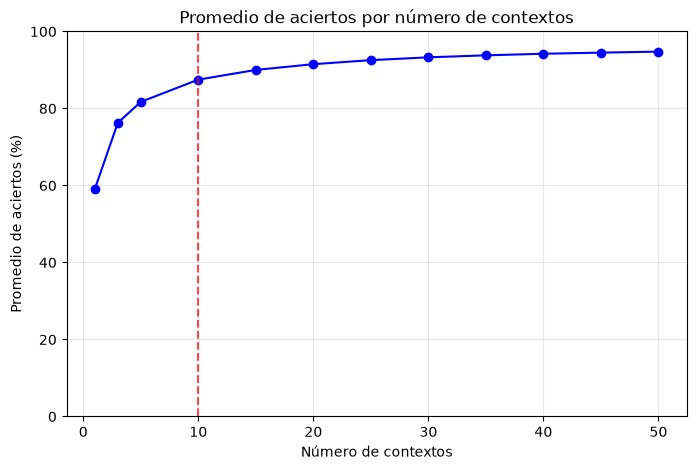

In [43]:
csv_porcentaje_titulos = r"C:\Users\playe\Documents\Trabajos\TFG-RAG-VDB\src\Resulsts\benchmark_miniL6_50_aciertos_contextos.csv"

df_analisis_aciertos = pd.read_csv(csv_porcentaje_titulos)

vectores_aprox = [1, 3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
y = [df_analisis_aciertos[f'Hit_Rate_{n}'].str.rstrip('%').astype(float).mean() for n in vectores_aprox]

plt.figure(figsize=(8, 5))
plt.plot(vectores_aprox, y, marker='o', linestyle='-', color='blue')

punto_optimo_x = vectores_aprox[0]
umbral_ganancia = 1.0 # Paramos cuando añadir 1 contexto aporte menos de un 1% de acierto

for i in range(1, len(vectores_aprox)):
    delta_y = y[i] - y[i-1] # Cuánto sube el acierto
    delta_x = vectores_aprox[i] - vectores_aprox[i-1] # Cuántos contextos hemos añadido
    
    ganancia_por_contexto = delta_y / delta_x
    
    if ganancia_por_contexto < umbral_ganancia:
        # Si la ganancia es menor al umbral, el óptimo era el punto anterior
        punto_optimo_x = vectores_aprox[i-1]
        break
plt.axvline(x=punto_optimo_x, color='red', linestyle='--', alpha=0.7, label='Punto Óptimo (Top-5)')

plt.title('Promedio de aciertos por número de contextos')
plt.xlabel('Número de contextos')
plt.ylabel('Promedio de aciertos (%)')
plt.ylim([0, 100])
plt.grid(True, alpha=0.3)
plt.show()

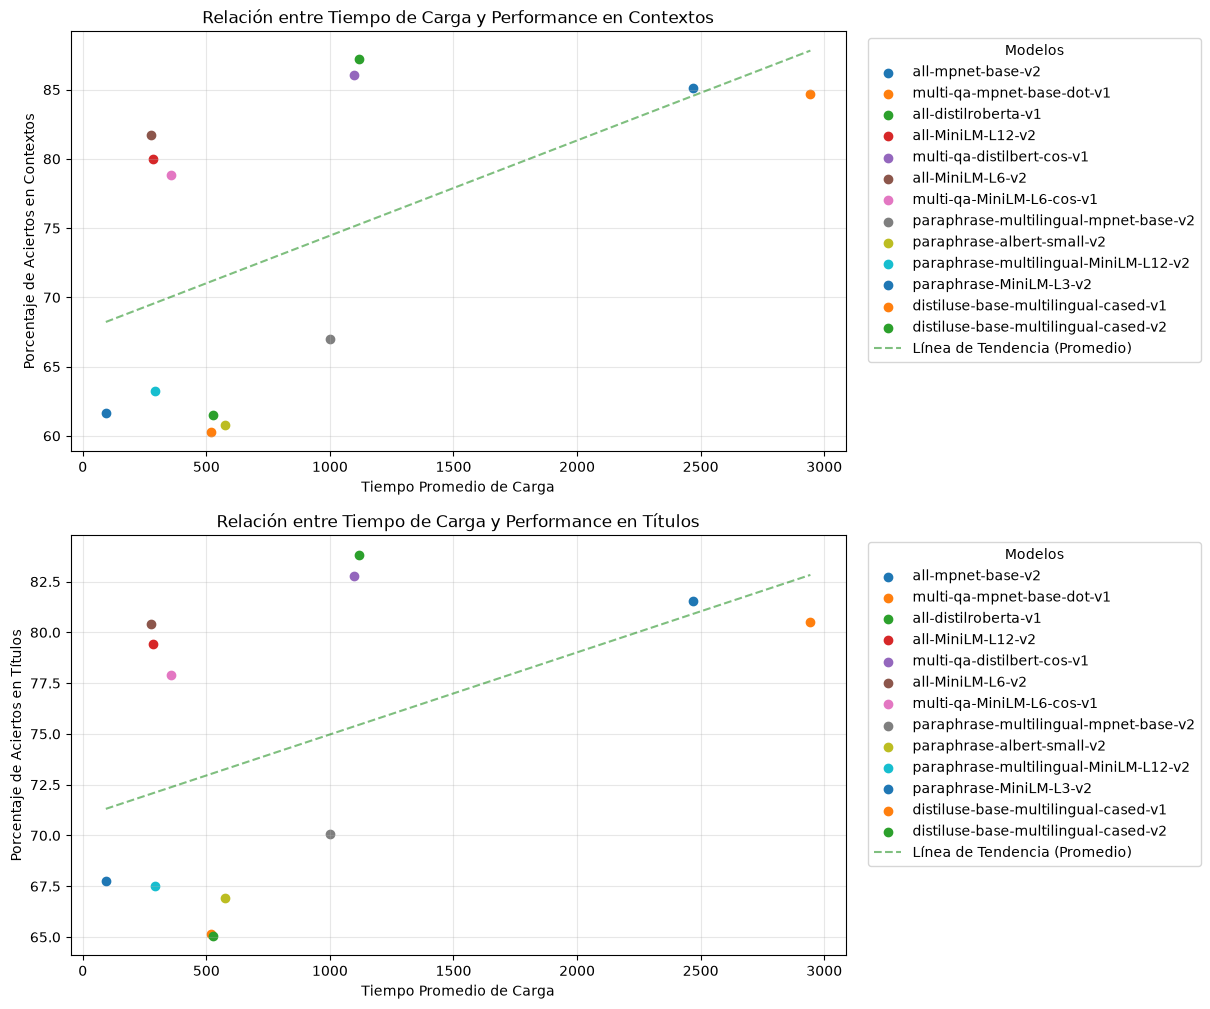

In [ ]:
x_tiempo = df_tiempos['func_tiempo_carga']
# Convertir a float después de eliminar el símbolo '%'
y_porcentaje_contextos = df_contextos['Hit_Rate_3'].str.rstrip('%').astype(float)
y_porcentaje_titulos = df_titulos['Hit_Rate_3'].str.rstrip('%').astype(float)
modelos = df_contextos['Modelo']


fig, axes = plt.subplots(2, 1, figsize=(10, 12))

for i in range(len(modelos)):
    axes[0].scatter(x_tiempo[i], y_porcentaje_contextos[i], label=modelos[i])

# tendencia lineal: y = mx + b 
#   Variables:
# y: porcentaje de aciertos sobre contextos
# x: tiempo

#   Coeficientes:
# b: constante de valor y en un supuesto x=0
# m: pendiente de la línea
coeficientes = np.polyfit(x_tiempo, y_porcentaje_contextos, 1) # [m, b]
polinomio = np.poly1d(coeficientes) # f(x) = mx + b
x_trend = np.linspace(x_tiempo.min(), x_tiempo.max(), 100)

axes[0].plot(x_trend, polinomio(x_trend), "g--", alpha=0.5, label='Línea de Tendencia (Promedio)')

axes[0].set_xlabel('Tiempo Promedio de Carga')
axes[0].set_ylabel('Porcentaje de Aciertos en Contextos')
axes[0].set_title('Relación entre Tiempo de Carga y Performance en Contextos')
axes[0].legend(title='Modelos', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)


for i in range(len(modelos)):
    axes[1].scatter(x_tiempo[i], y_porcentaje_titulos[i], label=modelos[i])

coeficientes = np.polyfit(x_tiempo, y_porcentaje_titulos, 1) # [m, b]
polinomio = np.poly1d(coeficientes) # f(x) = mx + b
x_trend = np.linspace(x_tiempo.min(), x_tiempo.max(), 100)

axes[1].plot(x_trend, polinomio(x_trend), "g--", alpha=0.5, label='Línea de Tendencia (Promedio)')

axes[1].set_xlabel('Tiempo Promedio de Carga')
axes[1].set_ylabel('Porcentaje de Aciertos en Títulos')
axes[1].set_title('Relación entre Tiempo de Carga y Performance en Títulos')
axes[1].legend(title='Modelos', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.show()